# Flow matching

In [1]:
import torch
from torch import nn, optim
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt

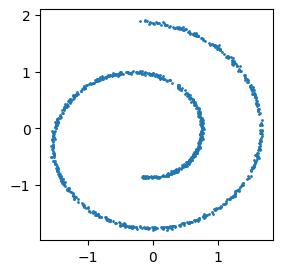

In [2]:
def get_batch(batch_size=1000, noise=0.1):
    x, _ = make_swiss_roll(batch_size, noise=noise)
    x = x[:, [0, 2]]
    x = (x - x.mean()) / x.std()
    return torch.tensor(x).float()

x = get_batch()
plt.figure(figsize=(3, 3))
plt.scatter(x[:, 0], x[:, 1], s=1)
plt.show()

In [3]:
class VectorField(nn.Module):

    def __init__(self, data_dim=2):
        super().__init__()

        self.data_dim = data_dim

        self.mlp = nn.Sequential(
            nn.Linear(data_dim + 1, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, data_dim)
        )

    def forward(self, x_t, t):
        # x_t: [batch_size, data_dim]
        # t: [batch_size, 1]
        input = torch.cat([x_t, t], dim=1)
        return self.mlp(input)

In [4]:
class FlowMatching:

    def __init__(self, velocity_net):
        self.velocity_net = velocity_net
        self.optimizer = optim.Adam(velocity_net.parameters())
        self.data_dim = velocity_net.data_dim
    
    def train(self, n_iters=5000):

        loss_fn = nn.MSELoss()

        for _ in range(n_iters):

            x_1 = get_batch()
            t = torch.rand([len(x_1), 1])
            x_0 = torch.randn_like(x_1)
            x_t = t * x_1 + (1-t) * x_0

            f_t_pred = self.velocity_net(x_t, t)
            f_t_real = x_1 - x_0

            loss = loss_fn(f_t_pred, f_t_real)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def generate_samples(self, n_samples=5000, n_steps=1000):

        # Ruido inicial x_0:
        x_t = torch.randn(n_samples, self.data_dim)

        # Algoritmo de Euler para la ODE:
        timesteps = torch.linspace(0, 1, n_steps)
        dt = timesteps[1] - timesteps[0]
        for t in timesteps:
            t = torch.empty([len(x_t), 1]).fill_(t)
            x_t = x_t + self.velocity_net(x_t, t) * dt

        return x_t.detach()

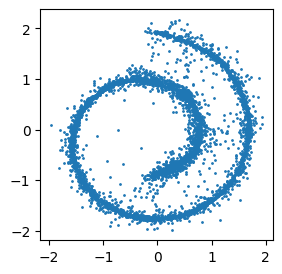

In [5]:
# Entrenamiento:
velocity_net = VectorField()
fm = FlowMatching(velocity_net)
fm.train()

# Generación:
x_1 = fm.generate_samples()
plt.figure(figsize=(3, 3))
plt.scatter(x_1[:, 0], x_1[:, 1], s=1)
plt.show()